In [56]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
import numpy as np

In [2]:
def in_stateA(q, s):
    return q<-0.8 and s == 0

def in_stateB(q, s):
    return q>0.8 and s == 0

In [25]:
v_init = -0.05
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 2000

SHO_H = DoubleHarmonic(k=0.1, x0=1.0, vc=0.4*0.05)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

Hop search finished after 29 iterations. Hop is located at x=-0.0721103451373447.
Hop is allowed, at time 4
Hop search finished after 29 iterations. Hop is located at x=0.022558385405675646.
Hop is allowed, at time 81
Hop search finished after 29 iterations. Hop is located at x=-0.18909711826429576.
Hop is allowed, at time 175
Hop search finished after 29 iterations. Hop is located at x=0.28390476097773976.
Hop is allowed, at time 252
Hop search finished after 29 iterations. Hop is located at x=-0.4501251472406337.
Hop is allowed, at time 346
Hop search finished after 26 iterations. Hop is located at x=0.22176398199439884.
Hop is allowed, at time 497


In [47]:
selector = UniformShootingSelector(temp=300, mass=1836.15, alpha=0.9)
current_traj = seed_traj
tps_ensemble = [current_traj]

n_tps_iterations = 1000
max_traj_length = 2000

pad_L = 1
pad_R = 1

accept = 0
reject = 0

for i in range(n_tps_iterations):
    print(f"--- TPS Iteration {i} ---")
    shooting_snap, l_old = selector.select_and_perturb(current_traj, pad_L=pad_L, pad_R=pad_R)
    engine_fwd = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=shooting_snap)
    traj_fwd = engine_fwd.propagate_until_basin(max_traj_length, in_stateA, in_stateB)

    shooting_snap_rev = shooting_snap.reversed()
    engine_bwd = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=shooting_snap_rev)
    traj_bwd_raw = engine_bwd.propagate_until_basin(max_traj_length, in_stateA, in_stateB)
    traj_bwd_fixed = [snap.reversed() for snap in reversed(traj_bwd_raw)]

    stitched_states = traj_bwd_fixed[:-1] + list(traj_fwd)
    trial_traj = Trajectory(stitched_states)

    start_q = trial_traj[0].positions
    end_q = trial_traj[-1].positions

    start_s = trial_traj[0].active_state
    end_s = trial_traj[-1].active_state

    connected = False
    if in_stateA(start_q, start_s) and in_stateB(end_q, end_s): connected = True
    if in_stateB(start_q, start_s) and in_stateA(end_q, end_s): connected = True

    L_new_grid = sum(1 for snap in trial_traj if snap.is_grid)
    l_new = L_new_grid - pad_L - pad_R

    if l_new > 0 and selector.check_acceptance(l_old, l_new, connected):
        current_traj = trial_traj
        print("ACCEPTED")
        accept += 1
    else:
        print("REJECTED")
        reject += 1
        
    
    tps_ensemble.append(current_traj)

print(f"TPS finished! Ensemble size: {len(tps_ensemble)}")
    

--- TPS Iteration 0 ---
Hop search finished after 28 iterations. Hop is located at x=0.21164392543546962.
Hop is allowed, at time 2
Hop search finished after 26 iterations. Hop is located at x=0.19156129124941784.
Hop is allowed, at time 76
REJECTED
--- TPS Iteration 1 ---
REJECTED
--- TPS Iteration 2 ---
Hop search finished after 27 iterations. Hop is located at x=0.40001816793344636.
Hop is allowed, at time 306
Hop search finished after 28 iterations. Hop is located at x=-0.4231427664686858.
Hop is allowed, at time 154
ACCEPTED
--- TPS Iteration 3 ---
Hop search finished after 29 iterations. Hop is located at x=-0.015950012084964025.
Hop is allowed, at time 34
Hop search finished after 29 iterations. Hop is located at x=0.03694608959739305.
Hop is allowed, at time 42
REJECTED
--- TPS Iteration 4 ---
Hop search finished after 27 iterations. Hop is located at x=-0.44512236366500824.
Hop is allowed, at time 128
Hop search finished after 28 iterations. Hop is located at x=0.4773248995725

In [48]:
acceptance_ratio = accept/(accept+reject)
print(acceptance_ratio)

0.42


In [60]:
def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

production_ensemble = tps_ensemble[200:]
production_ensemble = [remove_off_grid(traj) for traj in production_ensemble]

dt = 5
transit_times = [len(traj) * dt for traj in production_ensemble]
transit_times.pop(0)

mean_time = np.mean(transit_times)
std_time = np.std(transit_times)

print(f"Mean Transition Time: {mean_time:.2f} atomic units")
print(f"Standard Deviation: {std_time:.2f} atomic units")

Mean Transition Time: 558.34 atomic units
Standard Deviation: 79.74 atomic units


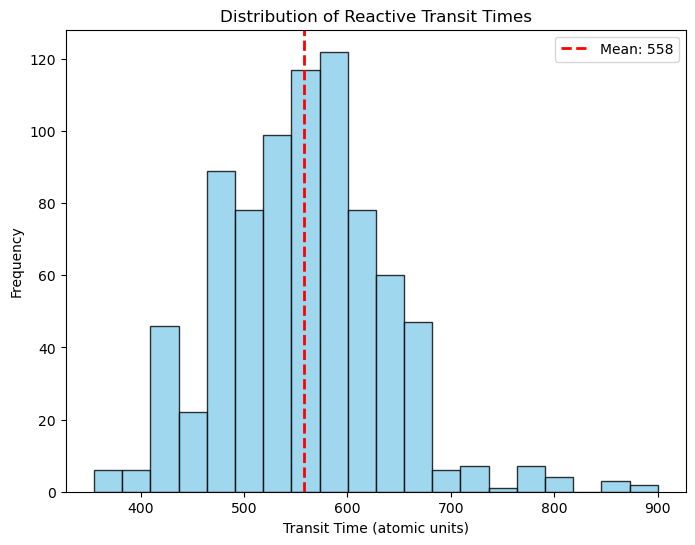

In [61]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(transit_times, bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Distribution of Reactive Transit Times")
plt.xlabel("Transit Time (atomic units)")
plt.ylabel("Frequency")
plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.0f}')
plt.legend()
plt.show()

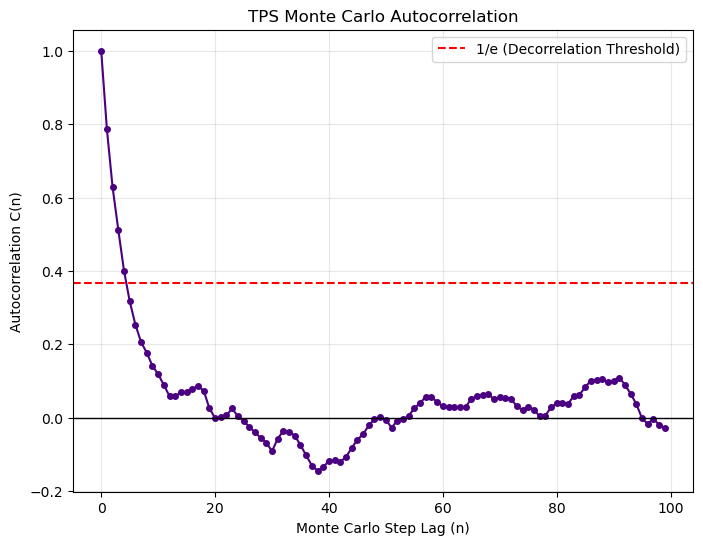

In [62]:
def compute_autocorrelation(data, max_lag=100):
    """Computes the normalized autocorrelation function of a 1D array."""
    mean = np.mean(data)
    var = np.var(data)
    data_centered = np.array(data) - mean
    
    N = len(data)
    autocorr = []
    
    for lag in range(max_lag):
        if lag == 0:
            autocorr.append(1.0)
        else:
            # Calculate covariance at the given lag
            cov = np.sum(data_centered[:-lag] * data_centered[lag:]) / (N - lag)
            autocorr.append(cov / var)
            
    return autocorr

# 1. Calculate the autocorrelation of your transit times
max_mc_lag = 100 # Look at correlation over 100 MC steps
C_n = compute_autocorrelation(transit_times, max_lag=max_mc_lag)

# 2. Plot the result
plt.figure(figsize=(8, 6))
plt.plot(range(max_mc_lag), C_n, marker='o', markersize=4, linestyle='-', color='indigo')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(np.exp(-1), color='red', linestyle='dashed', label='1/e (Decorrelation Threshold)')

plt.title("TPS Monte Carlo Autocorrelation")
plt.xlabel("Monte Carlo Step Lag (n)")
plt.ylabel("Autocorrelation C(n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [66]:
hop_counts = [sum(1 for snap in traj if not snap.is_grid) for traj in tps_ensemble]


mean_hops = np.mean(hop_counts)
std_hops = np.std(hop_counts)

print(f"Mean Number of Hops: {mean_hops:.6f}")
print(f"Standard Deviation of Hops: {std_hops:.6f}")

Mean Number of Hops: 0.233766
Standard Deviation of Hops: 1.082648
